In [1]:
import rebound
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from scipy.integrate import quad

In [2]:
#copyting my function from last's week's work to get the analytically calculated frequencies using secular threory as outlined in chapter 7

m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def get_freq_of_peri(alpha,n_jup,n_sat):
    laplace_coeff_1 = np.pi**(-1)*quad(lambda x: np.cos(x)/(1-2*alpha*np.cos(x) + alpha**2)**(3/2),0,2*np.pi)[0]
    laplace_coeff_2 = np.pi**(-1)*quad(lambda x: np.cos(2*x)/(1-2*alpha*np.cos(x) + alpha**2)**(3/2),0,2*np.pi)[0]

    A_11 = n_jup*0.25*(m_sat/(m_c + m_jup))*(alpha**2)*laplace_coeff_1
    A_22 = n_sat*0.25*(m_jup/(m_c + m_sat))*alpha*laplace_coeff_1
    A_12 = -n_jup*0.25*(m_sat/(m_c + m_jup))*(alpha**2)*laplace_coeff_2
    A_21 = -n_sat*0.25*(m_jup/(m_c + m_sat))*alpha*laplace_coeff_2

    sols = np.roots([1,-(A_11 + A_22),A_11*A_22 - A_12*A_21])
    g_1 = sols[0]
    g_2 = sols[1]

    print(np.roots([1,-(A_11 + A_22),A_11*A_22 - A_12*A_21]))
    return g_1,g_2  

In [3]:
#fourrier transform functions

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

def hk_ft(times,pomega,ecc):
    f,pxx = ft(times, ecc*np.cos(pomega))
    return f,pxx

def ecc_ft(times,ecc):
    f,pxx = ft(times, ecc)
    return f,pxx

## Sanity Checks

In [4]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
#textbook given values (Chapter 7) for 1983 where I have set inc and Omega to 0
sim.add(m=m_jup,a=5.202545,e=0.0474622,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=9.554841,e=0.0575481,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.202545/9.554841

sim.move_to_com()

In [5]:
times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

g_1,g_2 = get_freq_of_peri(alpha,sim.particles[1].n,sim.particles[2].n)

for i in range(len(times)):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    long_peri_j[i] = sim.particles[1].pomega
    e_j[i] = sim.particles[1].e

[1.75117422e-05 2.69998521e-06]


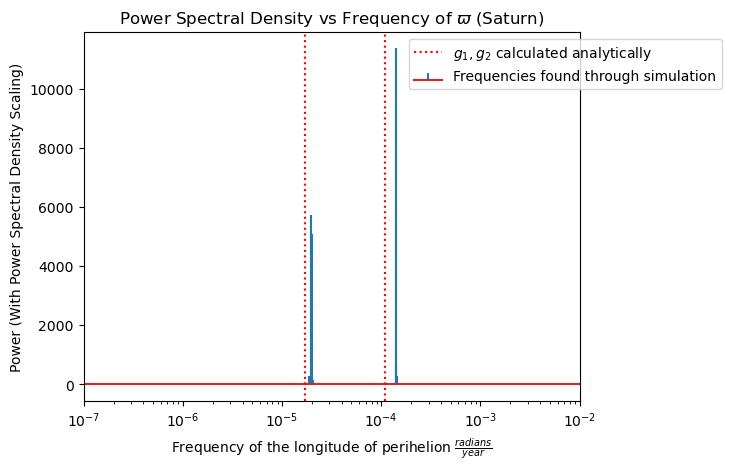

In [6]:
#Preforming the fourrier transfrom on pomega of Saturn
f,pxx = pomega_ft(times, long_peri_sat, e_sat)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.axvline(x=g_1*2*np.pi,c="r", ls = ':',label = r'$g_1,g_2$ calculated analytically')
plt.axvline(x=g_2*2*np.pi,c="r", ls = ':')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency of $\varpi$ (Saturn)')
plt.legend(bbox_to_anchor=(1.3, 1))
plt.show()

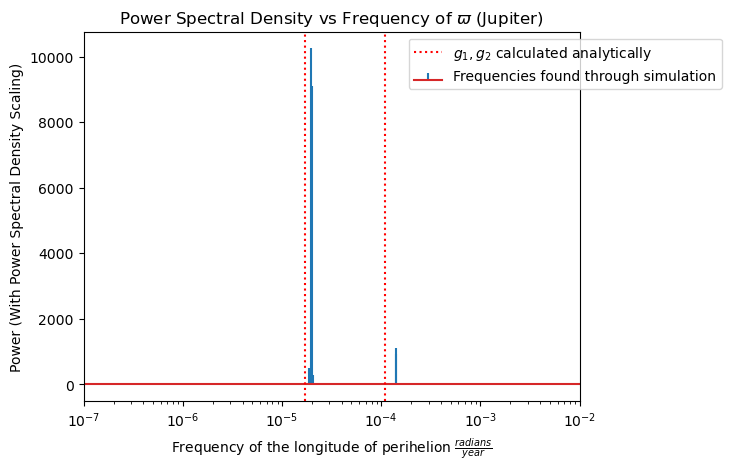

In [7]:
#preforming on pomega of Jupiter

f,pxx = pomega_ft(times, long_peri_j,e_j)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.axvline(x=g_1*2*np.pi,c="r", ls = ':',label = r'$g_1,g_2$ calculated analytically')
plt.axvline(x=g_2*2*np.pi,c="r", ls = ':')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency of $\varpi$ (Jupiter)')
plt.legend(bbox_to_anchor=(1.3, 1))
plt.show()

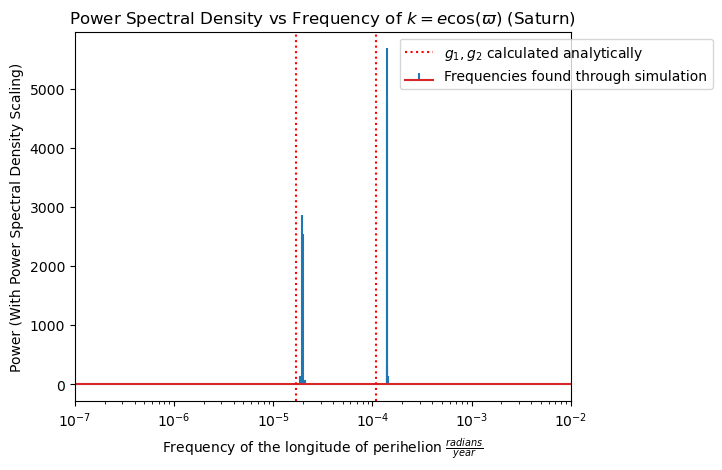

In [7]:
#taking the fourrier transform of just h element

f,pxx = hk_ft(times,long_peri_sat,e_sat)


plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.axvline(x=g_1*2*np.pi,c="r", ls = ':',label = r'$g_1,g_2$ calculated analytically')
plt.axvline(x=g_2*2*np.pi,c="r", ls = ':')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency of $k = e\cos(\varpi)$ (Saturn)')
plt.legend(bbox_to_anchor=(1.3, 1))
plt.show()

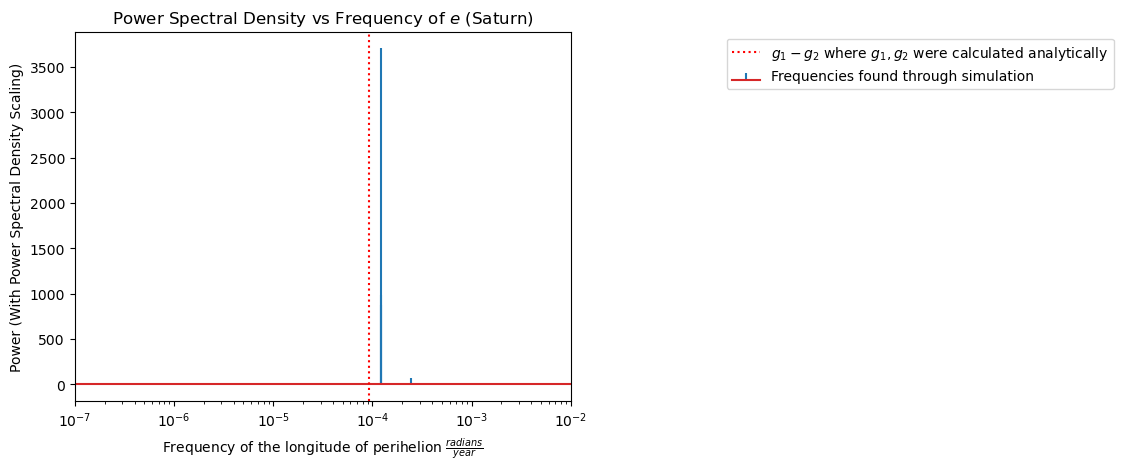

In [12]:
#taking the fourrier transform of just the eccentricity of Saturn
f,pxx = ecc_ft(times, e_sat)

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.axvline(x=np.abs(g_1-g_2)*2*np.pi,c="r", ls = ':',label = r'$g_1 - g_2$ where $g_1,g_2$ were calculated analytically')

plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency of $e$ (Saturn)')
plt.legend(bbox_to_anchor=(1.3, 1))
plt.show()